🔥STEP 1: Generate Dataset



In [11]:
import pandas as pd
import numpy as np

np.random.seed(42)
n = 1500

df = pd.DataFrame({
    "user_id": range(1, n+1),
    "purchase_frequency": np.zeros(n),
    "avg_order_value": np.zeros(n),
    "cart_abandonment_rate": np.zeros(n)
})

# Strong clusters

for i in range(n):
    if i < 500:
        # High-value customers
        df.loc[i, "purchase_frequency"] = np.random.randint(30, 50)
        df.loc[i, "avg_order_value"] = np.random.uniform(300, 500)
        df.loc[i, "cart_abandonment_rate"] = np.random.uniform(0, 0.2)

    elif i < 1000:
        # Medium customers
        df.loc[i, "purchase_frequency"] = np.random.randint(15, 30)
        df.loc[i, "avg_order_value"] = np.random.uniform(150, 300)
        df.loc[i, "cart_abandonment_rate"] = np.random.uniform(0.2, 0.5)

    else:
        # Low-value customers
        df.loc[i, "purchase_frequency"] = np.random.randint(1, 15)
        df.loc[i, "avg_order_value"] = np.random.uniform(10, 150)
        df.loc[i, "cart_abandonment_rate"] = np.random.uniform(0.5, 1)

df.head()

,user_id,purchase_frequency,avg_order_value,cart_abandonment_rate
0,1,36.0,459.308597,0.036687
1,2,37.0,419.731697,0.031204
2,3,48.0,319.994983,0.091850
3,4,33.0,328.573364,0.130178
4,5,31.0,444.399754,0.187711


🔥 STEP 2: Feature Scaling

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
features_for_scaling = ["purchase_frequency", "avg_order_value", "cart_abandonment_rate"]
X_scaled = scaler.fit_transform(df[features_for_scaling])

🔥 STEP 3: Find Optimal Clusters (Elbow Method)

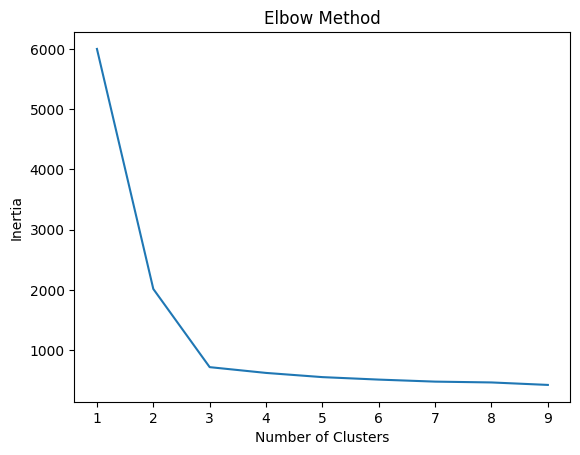

In [13]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 10), inertia)
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

🔥 Step 4: Try multiple K

In [8]:
for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print("K:", k, "Score:", score)

🔥 STEP 5: Apply K-Means

In [24]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

🔥STEP 6: Evaluate Model

In [25]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, clusters)
print("Silhouette Score:", score)

Silhouette Score: 0.5980781193324838


🔥 STEP 7: Analyze Clusters

In [26]:
df.groupby("Cluster").mean()

,user_id,purchase_frequency,avg_order_value,cart_abandonment_rate
Cluster,,,,
0,751.145709,21.956088,223.129177,0.346759
1,1250.853707,7.509018,81.728587,0.758072
2,250.500000,39.518000,397.364038,0.101462


🔥 STEP 8: Visualization

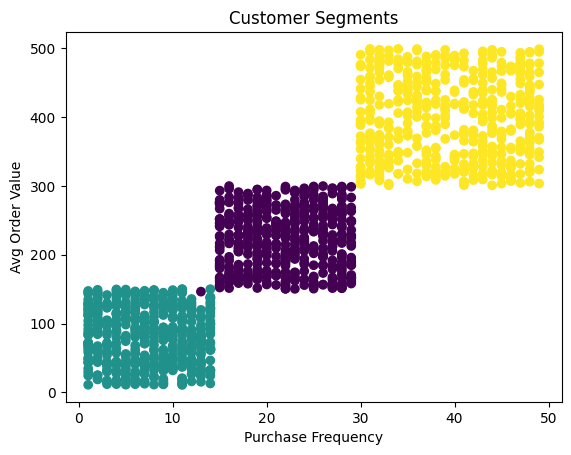

In [27]:
import matplotlib.pyplot as plt

plt.scatter(df["purchase_frequency"], df["avg_order_value"], c=df["Cluster"])
plt.xlabel("Purchase Frequency")
plt.ylabel("Avg Order Value")
plt.title("Customer Segments")
plt.show()

### Test with custom input features

In [29]:
# Get user input for test features
purchase_freq_input = float(input("Enter Purchase Frequency (e.g., 45): "))
avg_order_value_input = float(input("Enter Average Order Value (e.g., 450): "))
cart_abandonment_rate_input = float(input("Enter Cart Abandonment Rate (e.g., 0.1): "))

# Create a DataFrame for the single test case
custom_test_data = pd.DataFrame({
    "purchase_frequency": [purchase_freq_input],
    "avg_order_value": [avg_order_value_input],
    "cart_abandonment_rate": [cart_abandonment_rate_input]
})

# Scale the custom test data using the existing scaler
# Ensure cell 1NHpTZp4BzXC has been run to fit the scaler correctly.
custom_test_scaled = scaler.transform(custom_test_data)

# Predict the cluster for the custom input
custom_predicted_cluster = kmeans.predict(custom_test_scaled)

print(f"\nInput Features: {custom_test_data.iloc[0].to_dict()}")
print(f"Predicted Cluster: {custom_predicted_cluster[0]}")

Enter Purchase Frequency (e.g., 45): 20
Enter Average Order Value (e.g., 450): 350
Enter Cart Abandonment Rate (e.g., 0.1): 0.9

Input Features: {'purchase_frequency': 20.0, 'avg_order_value': 350.0, 'cart_abandonment_rate': 0.9}
Predicted Cluster: 0
